# EDA Comparativo C-MAPSS FD001-FD004

Objetivo: comparar los cuatro subconjuntos C-MAPSS para entender como cambia la dificultad del problema al variar condiciones operativas y modos de falla.

Este notebook no reemplaza el EDA detallado de FD001. Sirve para decidir si la extension del proyecto puede ser evaluar generalizacion hacia escenarios mas complejos.


## 1. Setup


In [2]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "CMAPSSData").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.data import (
    FEATURE_COLUMNS,
    SENSOR_COLUMNS,
    SETTING_COLUMNS,
    SUBSETS,
    add_train_rul,
    last_cycle_rows,
    load_cmapss_subset,
    unit_last_cycles,
)
from src.eda import (
    constant_columns,
    correlation_with_target,
    dataset_overview,
    low_variance_columns,
    train_test_distribution_shift,
)

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
sns.set_theme(style="whitegrid")

FIGURES_DIR = PROJECT_ROOT / "figures" / "EDA"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


## 2. Carga de subsets

Los cuatro subsets tienen el mismo formato de columnas, pero distinto nivel de complejidad:

- FD001: una condicion operativa, un modo de falla.
- FD002: seis condiciones operativas, un modo de falla.
- FD003: una condicion operativa, dos modos de falla.
- FD004: seis condiciones operativas, dos modos de falla.


In [3]:
subset_meta = pd.DataFrame(
    [
        {"subset": "FD001", "conditions": 1, "fault_modes": 1},
        {"subset": "FD002", "conditions": 6, "fault_modes": 1},
        {"subset": "FD003", "conditions": 1, "fault_modes": 2},
        {"subset": "FD004", "conditions": 6, "fault_modes": 2},
    ]
)

subsets = {}
for subset in SUBSETS:
    data = load_cmapss_subset(subset, data_dir=PROJECT_ROOT / "CMAPSSData")
    train = add_train_rul(data.train)
    test_last = last_cycle_rows(data.test).merge(data.rul, on="unit", how="left")
    subsets[subset] = {
        "data": data,
        "train": train,
        "test_last": test_last,
    }

subset_meta


,subset,conditions,fault_modes
0,FD001,1,1
1,FD002,6,1
2,FD003,1,2
3,FD004,6,2


## 3. Tamaño de cada subset

Primero se compara cantidad de filas y motores en train/test. Esto define costo computacional y cantidad de trayectorias disponibles para validar.


In [4]:
overview_rows = []
for subset, item in subsets.items():
    data = item["data"]
    overview = dataset_overview(data.train, data.test, data.rul)
    overview.insert(0, "subset", subset)
    overview_rows.append(overview)

overview_all = pd.concat(overview_rows, ignore_index=True)
overview_all


,subset,dataset,rows,columns,units,missing_values,duplicated_rows
0,FD001,train,20631,26,100,0,0
1,FD001,test,13096,26,100,0,0
2,FD001,rul,100,2,100,0,0
3,FD002,train,53759,26,260,0,0
4,FD002,test,33991,26,259,0,0
5,FD002,rul,259,2,259,0,0
6,FD003,train,24720,26,100,0,0
7,FD003,test,16596,26,100,0,0
8,FD003,rul,100,2,100,0,0
9,FD004,train,61249,26,249,0,0


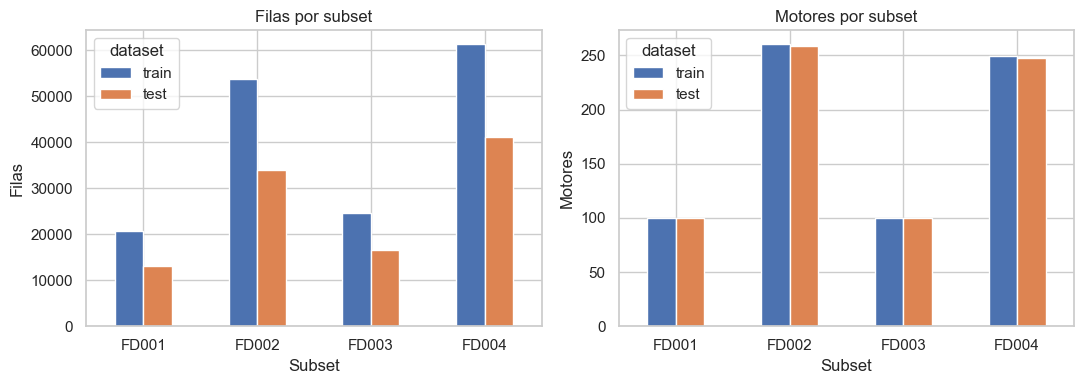

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
rows_pivot = overview_all.pivot(index="subset", columns="dataset", values="rows")
units_pivot = overview_all.loc[overview_all["dataset"].isin(["train", "test"])].pivot(
    index="subset", columns="dataset", values="units"
)
rows_pivot[["train", "test"]].plot(kind="bar", ax=axes[0])
axes[0].set_title("Filas por subset")
axes[0].set_xlabel("Subset")
axes[0].set_ylabel("Filas")
axes[0].tick_params(axis="x", rotation=0)

units_pivot[["train", "test"]].plot(kind="bar", ax=axes[1])
axes[1].set_title("Motores por subset")
axes[1].set_xlabel("Subset")
axes[1].set_ylabel("Motores")
axes[1].tick_params(axis="x", rotation=0)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "cmapss_subset_sizes.png", dpi=150)
plt.show()


## 4. Ciclos por motor

Los ciclos observados por motor indican la longitud de las trayectorias. En test las series estan truncadas antes de falla, asi que se comparan como longitud observada, no como vida total.


In [6]:
cycle_rows = []
for subset, item in subsets.items():
    data = item["data"]
    train_cycles = unit_last_cycles(data.train).assign(subset=subset, split="train")
    test_cycles = unit_last_cycles(data.test).assign(subset=subset, split="test")
    cycle_rows.extend([train_cycles, test_cycles])

cycles_all = pd.concat(cycle_rows, ignore_index=True)
cycle_summary = cycles_all.groupby(["subset", "split"])["last_cycle"].describe()
cycle_summary


count     mean     std      min      25%      50%      75%  \
subset split                                                                 
FD001  test  100.0000 130.9600 53.5935  31.0000  88.7500 133.5000 164.2500   
       train 100.0000 206.3100 46.3427 128.0000 177.0000 199.0000 229.2500   
FD002  test  259.0000 131.2394 63.0859  21.0000  76.5000 132.0000 168.0000   
       train 260.0000 206.7654 46.7822 128.0000 174.0000 199.0000 230.2500   
FD003  test  100.0000 165.9600 86.8918  38.0000 105.0000 148.0000 208.0000   
       train 100.0000 247.2000 86.4838 145.0000 189.7500 220.5000 279.7500   
FD004  test  248.0000 166.1855 91.6065  19.0000 102.0000 153.5000 218.5000   
       train 249.0000 245.9799 73.1108 128.0000 190.0000 234.0000 290.0000   

                  max  
subset split           
FD001  test  303.0000  
       train 362.0000  
FD002  test  367.0000  
       train 378.0000  
FD003  test  475.0000  
       train 525.0000  
FD004  test  486.0000  
       train 543.0000

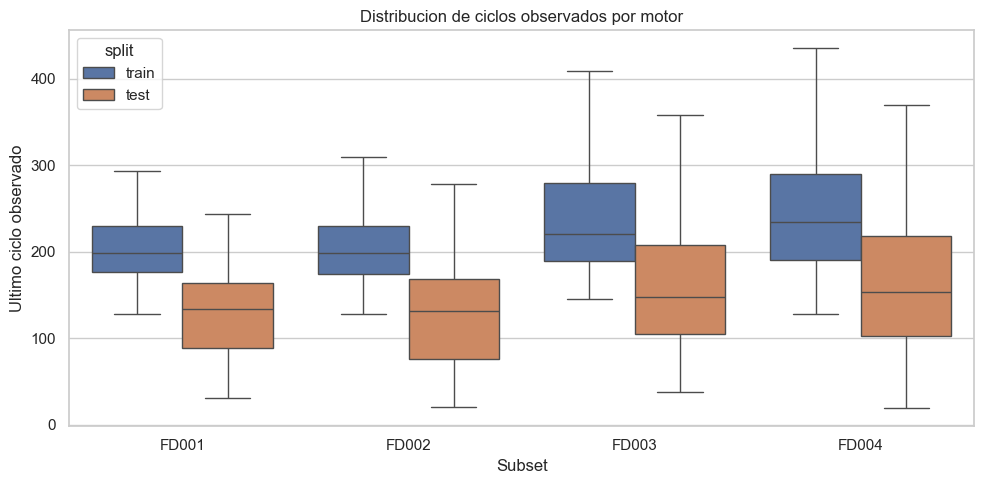

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.boxplot(data=cycles_all, x="subset", y="last_cycle", hue="split", ax=ax, showfliers=False)
ax.set_title("Distribucion de ciclos observados por motor")
ax.set_xlabel("Subset")
ax.set_ylabel("Ultimo ciclo observado")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "cmapss_cycles_by_subset.png", dpi=150)
plt.show()


## 5. Distribucion de RUL

En train el RUL se calcula por fila porque cada motor llega hasta falla. En test se usa `RUL_FD00X.txt`, que da una etiqueta por motor en el ultimo ciclo observado.


In [8]:
rul_rows = []
for subset, item in subsets.items():
    data = item["data"]
    train = item["train"]
    rul_rows.append(train[["RUL"]].assign(subset=subset, split="train_rows").rename(columns={"RUL": "rul"}))
    rul_rows.append(data.rul[["final_rul"]].assign(subset=subset, split="test_last_cycle").rename(columns={"final_rul": "rul"}))

rul_all = pd.concat(rul_rows, ignore_index=True)
rul_summary = rul_all.groupby(["subset", "split"])["rul"].describe()
rul_summary


count     mean     std    min     25%      50%  \
subset split                                                                  
FD001  test_last_cycle    100.0000  75.5200 41.7650 7.0000 32.7500  86.0000   
       train_rows      20,631.0000 107.8079 68.8810 0.0000 51.0000 103.0000   
FD002  test_last_cycle    259.0000  81.1853 53.8829 6.0000 35.0000  80.0000   
       train_rows      53,759.0000 108.1547 69.1806 0.0000 51.0000 103.0000   
FD003  test_last_cycle    100.0000  75.3200 41.6042 6.0000 43.2500  77.5000   
       train_rows      24,720.0000 138.0771 98.8467 0.0000 61.0000 123.0000   
FD004  test_last_cycle    248.0000  86.5524 54.6341 6.0000 36.0000  88.0000   
       train_rows      61,249.0000 133.3114 89.7834 0.0000 61.0000 122.0000   

                            75%      max  
subset split                              
FD001  test_last_cycle 112.2500 145.0000  
       train_rows      155.0000 361.0000  
FD002  test_last_cycle 121.0000 194.0000  
       train_rows      156.0000 377.0000  
FD003  test_last_cycle 115.0000 145.0000  
       train_rows      190.0000 524.0000  
FD004  test_last_cycle 126.7500 195.0000  
       train_rows      190.0000 542.0000

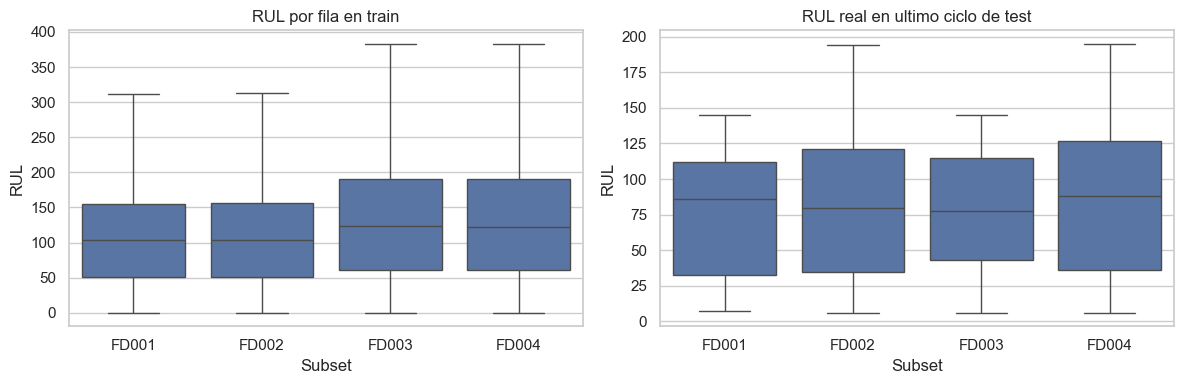

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.boxplot(data=rul_all.loc[rul_all["split"] == "train_rows"], x="subset", y="rul", ax=axes[0], showfliers=False)
axes[0].set_title("RUL por fila en train")
axes[0].set_xlabel("Subset")
axes[0].set_ylabel("RUL")

sns.boxplot(data=rul_all.loc[rul_all["split"] == "test_last_cycle"], x="subset", y="rul", ax=axes[1], showfliers=False)
axes[1].set_title("RUL real en ultimo ciclo de test")
axes[1].set_xlabel("Subset")
axes[1].set_ylabel("RUL")

fig.tight_layout()
fig.savefig(FIGURES_DIR / "cmapss_rul_by_subset.png", dpi=150)
plt.show()


## 6. Condiciones operativas

Las variables `setting_1`, `setting_2` y `setting_3` capturan el regimen operativo. En FD002 y FD004 deberian mostrar mas variabilidad porque tienen seis condiciones.


In [10]:
setting_rows = []
for subset, item in subsets.items():
    train = item["data"].train
    for column in SETTING_COLUMNS:
        setting_rows.append(
            {
                "subset": subset,
                "column": column,
                "n_unique": train[column].nunique(),
                "std": train[column].std(),
                "min": train[column].min(),
                "max": train[column].max(),
            }
        )
settings_summary = pd.DataFrame(setting_rows)
settings_summary


,subset,column,n_unique,std,min,max
0,FD001,setting_1,158,0.0022,-0.0087,0.0087
1,FD001,setting_2,13,0.0003,-0.0006,0.0006
2,FD001,setting_3,1,0.0000,100.0000,100.0000
3,FD002,setting_1,536,14.7474,0.0000,42.0080
4,FD002,setting_2,105,0.3100,0.0000,0.8420
5,FD002,setting_3,2,14.2377,60.0000,100.0000
6,FD003,setting_1,160,0.0022,-0.0086,0.0086
7,FD003,setting_2,14,0.0003,-0.0006,0.0007
8,FD003,setting_3,1,0.0000,100.0000,100.0000
9,FD004,setting_1,536,14.7807,0.0000,42.0080


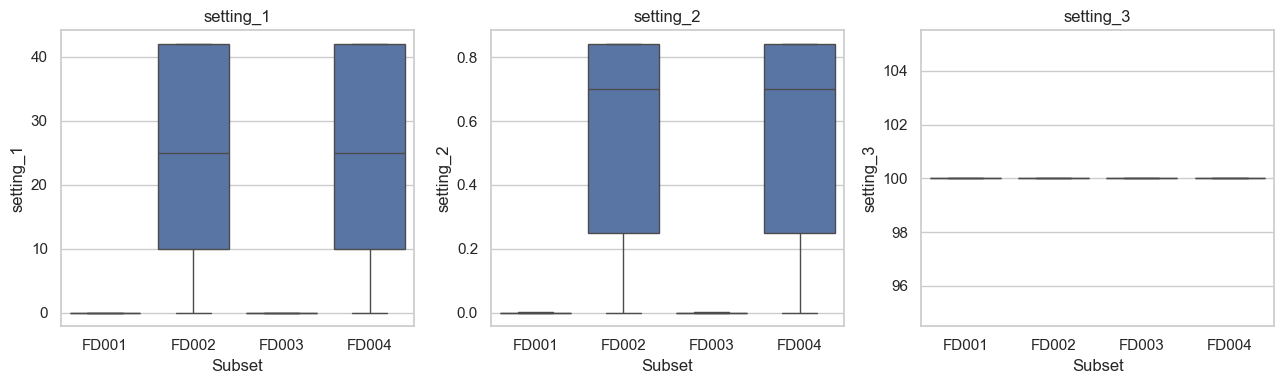

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, column in zip(axes, SETTING_COLUMNS):
    sns.boxplot(
        data=pd.concat(
            [item["data"].train[[column]].assign(subset=subset) for subset, item in subsets.items()],
            ignore_index=True,
        ),
        x="subset",
        y=column,
        ax=ax,
        showfliers=False,
    )
    ax.set_title(column)
    ax.set_xlabel("Subset")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "cmapss_settings_by_subset.png", dpi=150)
plt.show()


## 7. Columnas constantes y baja varianza

Las columnas constantes no aportan informacion predictiva dentro de un subset. La diferencia entre subsets ayuda a decidir si el preprocesamiento debe aprenderse por subset.


In [12]:
constant_rows = []
for subset, item in subsets.items():
    train_raw = item["data"].train
    constants = constant_columns(train_raw)
    low_var = low_variance_columns(train_raw)
    constant_rows.append(
        {
            "subset": subset,
            "n_constant_columns": len(constants),
            "constant_columns": ", ".join(constants) if constants else "",
            "n_low_variance_columns": len(low_var),
        }
    )
constant_summary = pd.DataFrame(constant_rows)
constant_summary


,subset,n_constant_columns,constant_columns,n_low_variance_columns
0,FD001,7,"setting_3, sensor_1, sensor_5, sensor_10, sens...",7
1,FD002,0,,0
2,FD003,6,"setting_3, sensor_1, sensor_5, sensor_16, sens...",6
3,FD004,0,,0


## 8. Correlacion sensores-RUL por subset

Esta comparacion muestra si los mismos sensores son informativos en todos los escenarios. No define causalidad ni reemplaza validacion con modelos.


In [13]:
corr_rows = []
for subset, item in subsets.items():
    train = item["train"]
    corr = correlation_with_target(train, target="RUL", columns=FEATURE_COLUMNS)
    sensor_corr = corr.loc[[column for column in corr.index if column in SENSOR_COLUMNS]].copy()
    sensor_corr = sensor_corr.reset_index().rename(columns={"index": "sensor"})
    sensor_corr.insert(0, "subset", subset)
    corr_rows.append(sensor_corr)

sensor_corr_all = pd.concat(corr_rows, ignore_index=True)
sensor_corr_all.sort_values(["subset", "abs_correlation"], ascending=[True, False]).groupby("subset").head(8)


,subset,sensor,correlation,abs_correlation
0,FD001,sensor_11,-0.6962,0.6962
1,FD001,sensor_4,-0.6789,0.6789
2,FD001,sensor_12,0.6720,0.6720
3,FD001,sensor_7,0.6572,0.6572
4,FD001,sensor_15,-0.6427,0.6427
5,FD001,sensor_21,0.6357,0.6357
6,FD001,sensor_20,0.6294,0.6294
7,FD001,sensor_2,-0.6065,0.6065
21,FD002,sensor_16,-0.0714,0.0714
22,FD002,sensor_11,-0.0469,0.0469


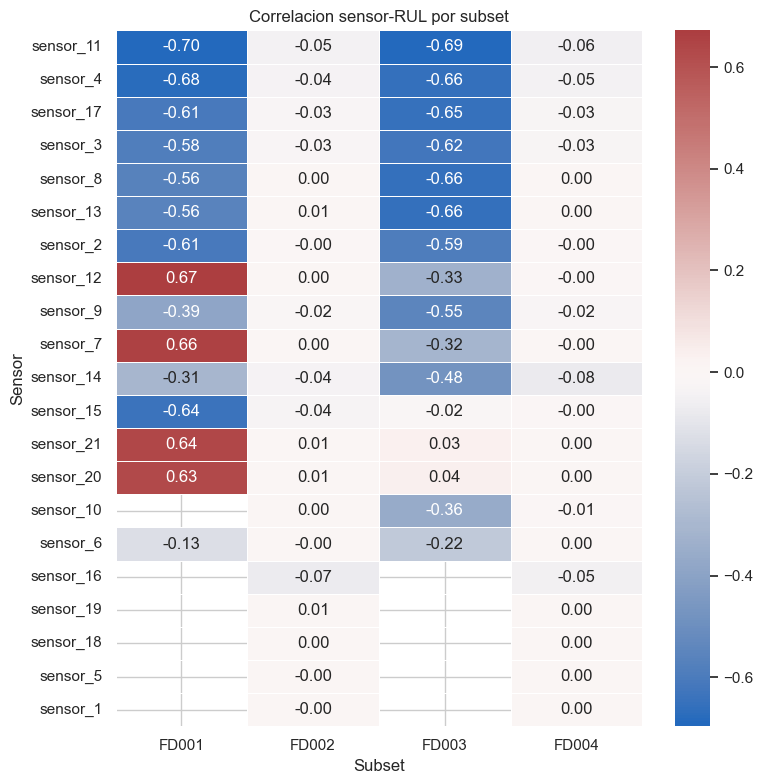

In [14]:
corr_matrix = sensor_corr_all.pivot(index="sensor", columns="subset", values="correlation")
ordered_sensors = corr_matrix.abs().mean(axis=1).sort_values(ascending=False).index
corr_matrix = corr_matrix.loc[ordered_sensors]

fig, ax = plt.subplots(figsize=(8, 8))
sns.heatmap(corr_matrix, cmap="vlag", center=0, annot=True, fmt=".2f", linewidths=0.4, ax=ax)
ax.set_title("Correlacion sensor-RUL por subset")
ax.set_xlabel("Subset")
ax.set_ylabel("Sensor")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "cmapss_sensor_rul_corr_heatmap.png", dpi=150)
plt.show()


## 9. Diferencia train/test observada

Se resume el mayor cambio de media estandarizada entre train y test para cada subset. Esto es solo un diagnostico: test esta truncado antes de falla, por lo que no tiene que verse igual que train completo.


In [15]:
shift_rows = []
for subset, item in subsets.items():
    data = item["data"]
    shift = train_test_distribution_shift(data.train, data.test, FEATURE_COLUMNS)
    top_shift = shift.head(5).copy()
    top_shift.insert(0, "subset", subset)
    shift_rows.append(top_shift)
shift_summary = pd.concat(shift_rows, ignore_index=True)
shift_summary[["subset", "column", "train_mean", "test_mean", "standardized_mean_diff"]]


,subset,column,train_mean,test_mean,standardized_mean_diff
0,FD001,sensor_10,1.3000,1.3000,1.0000
1,FD001,sensor_11,47.5412,47.4162,-0.5009
2,FD001,sensor_4,"1,408.9338","1,404.7354",-0.4979
3,FD001,sensor_12,521.4135,521.7477,0.4820
4,FD001,sensor_7,553.3677,553.7575,0.4674
5,FD002,sensor_16,0.0233,0.0231,-0.0394
6,FD002,sensor_14,"8,066.5977","8,063.6388",-0.0350
7,FD002,sensor_11,42.9852,42.9101,-0.0232
8,FD002,sensor_4,"1,205.4420","1,203.0865",-0.0198
9,FD002,sensor_15,9.3297,9.3152,-0.0193


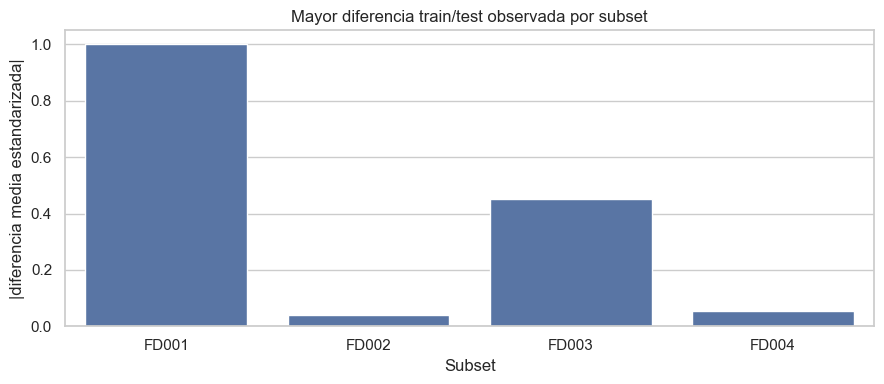

In [16]:
fig, ax = plt.subplots(figsize=(9, 4))
max_shift = (
    shift_summary.groupby("subset")["standardized_mean_diff"]
    .apply(lambda values: values.abs().max())
    .reset_index(name="max_abs_standardized_mean_diff")
)
sns.barplot(data=max_shift, x="subset", y="max_abs_standardized_mean_diff", ax=ax)
ax.set_title("Mayor diferencia train/test observada por subset")
ax.set_xlabel("Subset")
ax.set_ylabel("|diferencia media estandarizada|")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "cmapss_train_test_shift_by_subset.png", dpi=150)
plt.show()


## 10. Chequeo de cap de RUL

Una decision habitual en C-MAPSS es limitar el RUL maximo, por ejemplo a 125 ciclos. La idea es que al inicio de la vida util hay poca evidencia para distinguir con precision entre motores a los que les quedan muchos ciclos.

Este chequeo no define todavia el entrenamiento final; cuantifica cuanto cambiaria el target si se usa un cap.


In [20]:
RUL_CAP = 125

rul_cap_rows = []
for subset, item in subsets.items():
    train = item["train"]
    test_last = item["test_last"]

    rul_cap_rows.append(
        {
            "subset": subset,
            "train_rows": len(train),
            "train_pct_above_cap": (train["RUL"] > RUL_CAP).mean() * 100,
            "train_rul_mean_raw": train["RUL"].mean(),
            "train_rul_mean_capped": train["RUL"].clip(upper=RUL_CAP).mean(),
            "test_units": len(test_last),
            "test_pct_above_cap": (test_last["final_rul"] > RUL_CAP).mean() * 100,
            "test_rul_mean_raw": test_last["final_rul"].mean(),
            "test_rul_mean_capped": test_last["final_rul"].clip(upper=RUL_CAP).mean(),
        }
    )

rul_cap_summary = pd.DataFrame(rul_cap_rows)
rul_cap_summary


,subset,train_rows,train_pct_above_cap,train_rul_mean_raw,train_rul_mean_capped,test_units,test_pct_above_cap,test_rul_mean_raw,test_rul_mean_capped
0,FD001,20631,38.9269,107.8079,86.8293,100,11.0000,75.5200,74.4500
1,FD002,53759,39.0614,108.1547,86.9134,259,22.0077,81.1853,73.6911
2,FD003,24720,49.0291,138.0771,93.1432,100,15.0000,75.3200,73.7600
3,FD004,61249,48.7763,133.3114,92.9852,248,27.0161,86.5524,77.8589


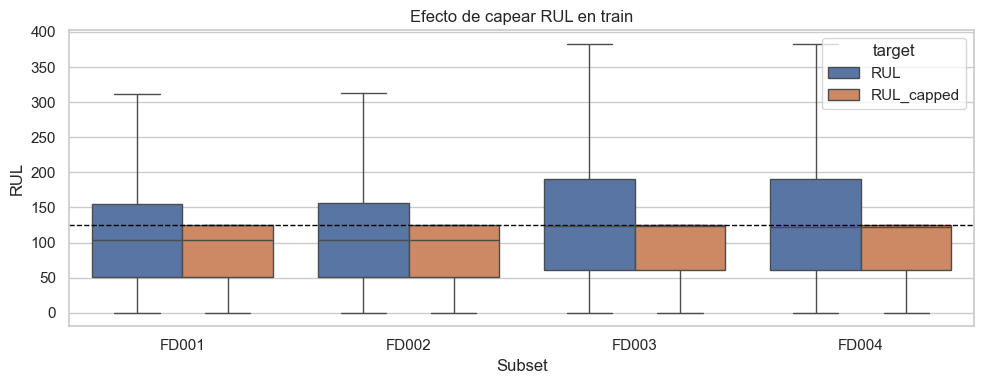

In [21]:
rul_plot_rows = []
for subset, item in subsets.items():
    train = item["train"][["RUL"]].copy()
    train["RUL_capped"] = train["RUL"].clip(upper=RUL_CAP)
    plot_data = train.melt(value_vars=["RUL", "RUL_capped"], var_name="target", value_name="rul")
    plot_data["subset"] = subset
    rul_plot_rows.append(plot_data)

rul_plot = pd.concat(rul_plot_rows, ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 4))
sns.boxplot(data=rul_plot, x="subset", y="rul", hue="target", ax=ax, showfliers=False)
ax.axhline(RUL_CAP, color="black", linestyle="--", linewidth=1, label=f"cap={RUL_CAP}")
ax.set_title("Efecto de capear RUL en train")
ax.set_xlabel("Subset")
ax.set_ylabel("RUL")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "cmapss_rul_cap_effect.png", dpi=150)
plt.show()


Lectura final:

- El EDA comparativo queda enfocado en diferencias entre subsets, conditions, distribuciones, correlaciones y cap de RUL.
- El analisis profundo de patrones de degradacion de FD003 se movio a `03_eda_fd003_patrones_degradacion.ipynb` para mantener este notebook ordenado.
